# IEDDA candidate distributions and distortion-fraction selection

The workflow first prepares the IEDDA comparison population, then compares its four energy distributions and 4pi distortion fraction with the complete curated literature reference. Candidate selection and screening-table exports follow the distribution analysis.

- **SI 6.3:** frontier-orbital gap classification (FMO context is plotted in notebook `04`).
- **SI 6.4:** four energy-distribution panels, followed by the 4pi distortion-fraction distribution.
- **SI 6.5:** apply the distortion-fraction criterion and export the selected pairs.

Both notebooks use all records in `Data/Reported_BO/Reported Bioorthogonal Reactions for Selection.csv`. Candidate energies are predictions; reference energies are DFT values. The reference is already curated and receives no additional energy, structural, or ratio filters here.

In [9]:
from pathlib import Path
import os
import sys

start = Path.cwd().resolve()
REPO_ROOT = next((p for p in (start, *start.parents)
                  if (p / "Code/model_train.py").is_file()), None)
if REPO_ROOT is None:
    raise FileNotFoundError("Start Jupyter inside the CycloAddGenerator repository.")
for folder in (REPO_ROOT / "notebooks", REPO_ROOT / "notebooks/04_discovery"):
    if str(folder) not in sys.path:
        sys.path.insert(0, str(folder))
os.chdir(REPO_ROOT)

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from IPython.display import display
from _workflow_paths import SCREEN_DIR, FMO_CSV, require_file
from _discovery_comparison import (
    REFERENCE_RELATIVE_PATH, POPULATION_STYLES, load_reference,
    orbital_gaps, energy_values, describe_populations, plot_frequency_curves,
)

plt.rcParams.update({"font.family": "sans-serif", "font.sans-serif": ["Arial", "DejaVu Sans"]})

## 1. Prepare the populations for comparison

Read the candidates remaining after the self-reaction filter. For the comparison population, identify IEDDA pairs by the strict inequality `LUMO(4pi) - HOMO(2pi) < LUMO(2pi) - HOMO(4pi)`. Saved orbital energies are already in eV. This preparation does not apply the distortion-fraction selection or write screening tables.

The complete reference CSV is loaded through the same helper used by notebook `04`. All subsequent distribution panels use these same two populations.

In [10]:
candidates = pd.read_csv(require_file(SCREEN_DIR / "3_DropDimer.csv"))
fmo = pd.read_csv(require_file(FMO_CSV)).set_index("Index")
gaps = orbital_gaps(candidates, fmo)
iedda_mask = gaps["inverse_gap"] < gaps["normal_gap"]
other_mask = gaps["inverse_gap"] > gaps["normal_gap"]
equal_mask = gaps["inverse_gap"] == gaps["normal_gap"]
comparison_candidates = candidates.loc[iedda_mask].copy()
reference = load_reference(REPO_ROOT)
predicted_values = energy_values(comparison_candidates, predicted=True)
reported_values = energy_values(reference)
populations = [
    (POPULATION_STYLES[0][0], predicted_values, POPULATION_STYLES[0][1]),
    (POPULATION_STYLES[1][0], reported_values, POPULATION_STYLES[1][1]),
]
print(f"Reference source: {REFERENCE_RELATIVE_PATH.as_posix()}")
display(pd.DataFrame([
    {"population": "After self-reaction exclusion", "n": len(candidates)},
    {"population": "IEDDA candidates before fraction selection", "n": len(comparison_candidates)},
    {"population": "Curated reported reference (all rows)", "n": len(reference)},
]))

Reference source: Data/Reported_BO/Reported Bioorthogonal Reactions for Selection.csv


,population,n
0,After self-reaction exclusion,2932
1,IEDDA candidates before fraction selection,1589
2,Curated reported reference (all rows),158


## 2. Compare four energy distributions — SI 6.4

Compare 4pi distortion, 2pi distortion, interaction energy, and total distortion. Each panel uses the original ratio figure's style: separately normalized histogram frequencies, cubic-spline curves, and translucent fills. Shared bin edges within each panel include the complete range of both populations.

The y-axis is **relative frequency per bin**, not probability density. Thirty edges give 29 bins, matching the original ratio plot. Spline curves are visual guides; summary statistics are calculated from the underlying values. Energies retain their stored signs. Total distortion is a descriptive comparison variable.

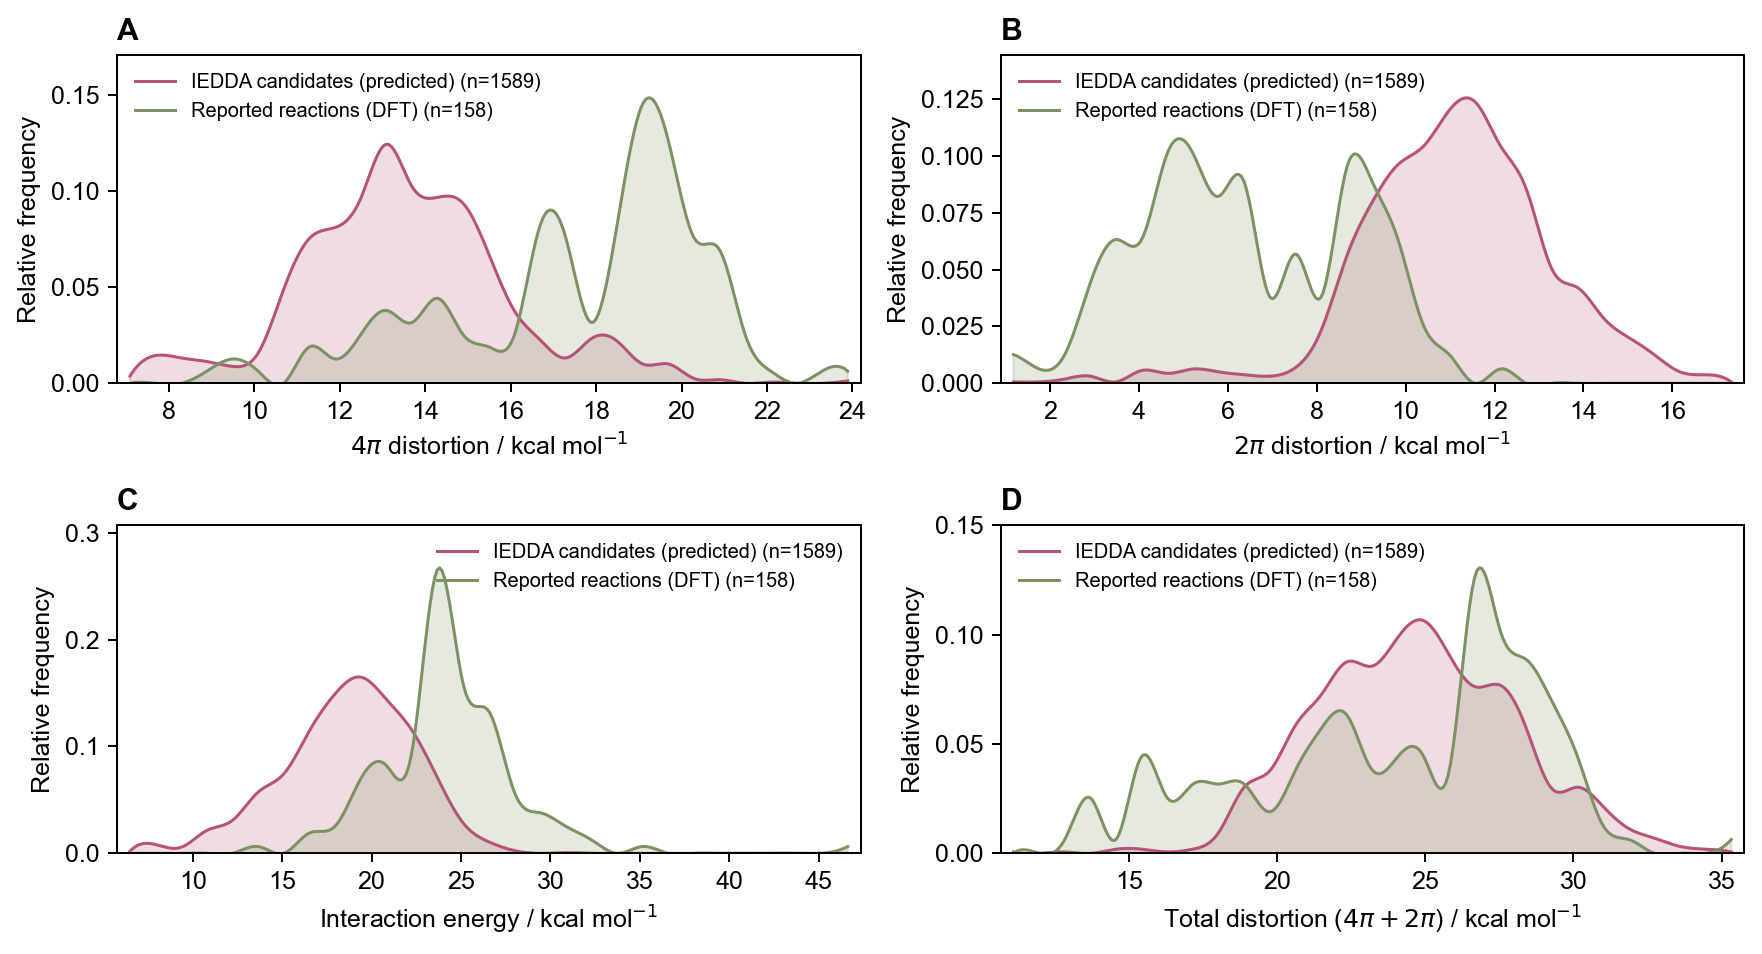

In [11]:
FIGURE_DIR = REPO_ROOT / "Figure/DI_selection_controls"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
energy_metrics = ["4pi distortion", "2pi distortion", "Interaction", "Total distortion"]
energy_labels = [r"$4\pi$ distortion", r"$2\pi$ distortion", "Interaction energy", r"Total distortion ($4\pi + 2\pi$)"]
fig, axes = plt.subplots(2, 2, figsize=(10, 5.4), dpi=180, facecolor="white")
for panel, ax, metric, label in zip("ABCD", axes.flat, energy_metrics, energy_labels):
    curves = [(f"{name} (n={len(frame)})", frame[metric], color)
              for name, frame, color in populations]
    plot_frequency_curves(ax, curves)
    ax.set_xlabel(label + r" / kcal mol$^{-1}$")
    ax.set_ylabel("Relative frequency")
    ax.set_title(panel, loc="left", fontweight="bold")
    ax.legend(frameon=False, fontsize=8)
fig.tight_layout()
for extension in ("png", "svg"):
    fig.savefig(FIGURE_DIR / f"iedda_reported_energy_distributions.{extension}", dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig)

## 3. Compare the 4pi distortion fraction — SI 6.4

Define `f4pi = E_dist,4pi / (E_dist,4pi + E_dist,2pi)`. Plot the fraction immediately after the four energy panels, using the same populations, colors, normalization, and interpolation style. Every IEDDA candidate is included before fraction selection.

The curated reference is shown as supplied. Its distribution is descriptive; this notebook does not optimize a screening threshold against it. The corresponding selection rule is applied in the next section.

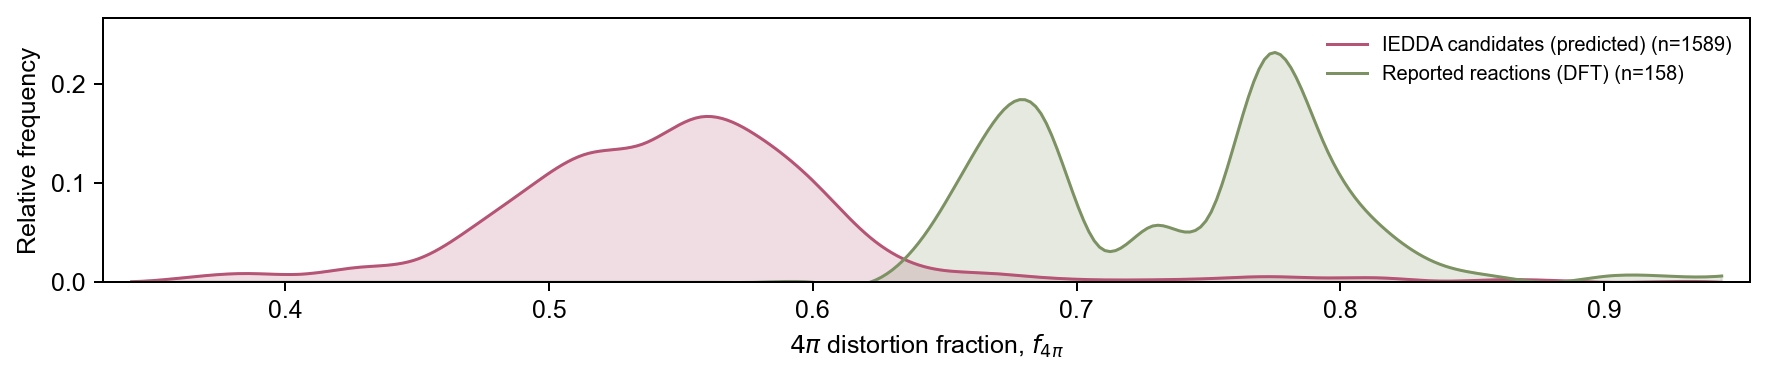

In [12]:
fraction_metric = "4pi distortion fraction"
curves = [(f"{name} (n={len(frame)})", frame[fraction_metric], color)
          for name, frame, color in populations]
fig, ax = plt.subplots(figsize=(10, 2.2), dpi=180, facecolor="white")
plot_frequency_curves(ax, curves)
ax.set_xlabel(r"$4\pi$ distortion fraction, $f_{4\pi}$")
ax.set_ylabel("Relative frequency")
ax.legend(frameon=False, fontsize=8)
fig.tight_layout()
for extension in ("png", "svg"):
    fig.savefig(FIGURE_DIR / f"iedda_reported_distortion_ratio.{extension}", dpi=300, bbox_inches="tight")
# Maintain the existing figure path used by manuscript drafts.
legacy_figure_dir = REPO_ROOT / "Data/Analysis_DI_Selection_Reported_BO"
legacy_figure_dir.mkdir(parents=True, exist_ok=True)
fig.savefig(legacy_figure_dir / "distortion_x_distribution.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig)

In [13]:
comparison_summary = describe_populations(populations)
distribution_summary = comparison_summary.loc[comparison_summary["metric"].isin(energy_metrics)].copy()
fraction_summary = comparison_summary.loc[comparison_summary["metric"] == fraction_metric].copy()
distribution_summary.to_csv(FIGURE_DIR / "iedda_reported_energy_distribution_summary.csv", index=False)
fraction_summary.to_csv(FIGURE_DIR / "iedda_reported_distortion_ratio_summary.csv", index=False)
display(comparison_summary)

,metric,population,n,excluded_nonfinite,mean,std,median,min,max
0,4pi distortion,IEDDA candidates (predicted),1589,0,13.563230,2.437901,13.433281,6.788932,24.191063
1,2pi distortion,IEDDA candidates (predicted),1589,0,11.108067,2.166351,11.169109,1.225726,17.616135
2,Interaction,IEDDA candidates (predicted),1589,0,18.735783,3.662237,19.015104,5.768351,30.364990
3,Total distortion,IEDDA candidates (predicted),1589,0,24.671297,3.345447,24.605850,10.677231,35.531035
4,4pi distortion fraction,IEDDA candidates (predicted),1589,0,0.549808,0.068046,0.548987,0.330943,0.922014
5,4pi distortion,Reported reactions (DFT),158,0,17.603060,2.986126,18.631362,8.761082,24.060900
6,2pi distortion,Reported reactions (DFT),158,0,6.443675,2.394192,6.151684,0.887092,12.225705
7,Interaction,Reported reactions (DFT),158,0,24.285667,3.818001,24.056891,13.610242,47.338487
8,Total distortion,Reported reactions (DFT),158,0,24.046734,4.817983,25.222207,12.663581,35.754623
9,4pi distortion fraction,Reported reactions (DFT),158,0,0.738956,0.061431,0.753844,0.640217,0.955366


## 4. Apply the candidate-selection rule — SI 6.5

After the distribution comparisons, retain IEDDA candidate pairs with `f4pi > 0.64`. The comparison populations above are not replaced by the selected subset. This stage exports both the IEDDA classification and the fraction-selected candidate tables for downstream procurement and DFT analysis.

All stage counts are calculated from the loaded data. Equal FMO gaps are reported separately and excluded from both strict-inequality branches.

In [14]:
FRACTION_THRESHOLD = 0.64
selected_mask = predicted_values[fraction_metric] > FRACTION_THRESHOLD
selected_candidates = comparison_candidates.loc[selected_mask].copy()
dropped_candidates = comparison_candidates.loc[~selected_mask].copy()
SCREEN_DIR.mkdir(parents=True, exist_ok=True)
comparison_candidates.to_csv(SCREEN_DIR / "4_IEDDA_select.csv", index=False)
candidates.loc[other_mask].to_csv(SCREEN_DIR / "4_IEDDA_drop.csv", index=False)
selected_candidates.to_csv(SCREEN_DIR / "5_DI_selected.csv", index=False)
dropped_candidates.to_csv(SCREEN_DIR / "5_DI_dropped.csv", index=False)
display(pd.DataFrame([
    {"stage": "After self-reaction exclusion", "pairs": len(candidates)},
    {"stage": "IEDDA", "pairs": len(comparison_candidates)},
    {"stage": "Opposite FMO-gap ordering", "pairs": int(other_mask.sum())},
    {"stage": "Equal FMO gaps", "pairs": int(equal_mask.sum())},
    {"stage": "Selected: f4pi > 0.64", "pairs": len(selected_candidates)},
    {"stage": "Excluded by fraction", "pairs": len(dropped_candidates)},
]))
print({"selected_4pi_reactants": selected_candidates["Diene_Index"].nunique(),
       "selected_2pi_reactants": selected_candidates["Ene_Index"].nunique()})

,stage,pairs
0,After self-reaction exclusion,2932
1,IEDDA,1589
2,Opposite FMO-gap ordering,1343
3,Equal FMO gaps,0
4,Selected: f4pi > 0.64,84
5,Excluded by fraction,1505


{'selected_4pi_reactants': 51, 'selected_2pi_reactants': 25}
